In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 0. 하이퍼파라미터
# ============================================================
hyp = dict(
    seed          = 42,
    epochs        = 50, #에포크
    lr            = 1e-4,
    batch_size    = 32,
    shared_dim    = 64,
    num_heads     = 4,
    dropout       = 0.5,
    weight_decay  = 1e-3,
    label_smooth  = 0.15,
    noise_std     = 0.02,
    mixup_alpha   = 0.1,
    modal_drop_p  = 0.15,
    patience      = 10,
    warmup_epochs = 5,
    smooth_window = 3,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(hyp["seed"])

Device: cuda


# 함수 정의

In [ ]:
class FeatureDataset(Dataset):
    def __init__(self, vid, aud, txt, y, noise_std=0.0):
        self.vid       = torch.tensor(vid, dtype=torch.float32)
        self.aud       = torch.tensor(aud, dtype=torch.float32)
        self.txt       = torch.tensor(txt, dtype=torch.float32)
        self.y         = torch.tensor(np.array(y), dtype=torch.long)
        self.noise_std = noise_std

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        v, a, t = self.vid[i], self.aud[i], self.txt[i]
        if self.noise_std > 0: # 노이즈가 0보다 크면 데이터에 잡음 섞어줌 -> 과적합 방지하기 위해
            v = v + torch.randn_like(v) * self.noise_std
            a = a + torch.randn_like(a) * self.noise_std
            t = t + torch.randn_like(t) * self.noise_std
        return v, a, t, self.y[i]

class ModalEncoder(nn.Module):
    def __init__(self, in_dim, shared_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim), #평균0, 분산1로 맞춰 스케일링
            nn.Linear(in_dim, shared_dim), #차원 축소
            nn.GELU(), #활성화 함수
            nn.Dropout(dropout), #과적함 방지
            nn.Linear(shared_dim, shared_dim), #차원 유지하며 학습
            nn.GELU(), # 활성화 함수
        )
    def forward(self, x):
        return self.net(x)


class SelfAttentionFusionModel(nn.Module):
    def __init__(self, in_dim, shared_dim=128, num_heads=4, num_classes=2,
                 dropout=0.3, modal_drop_p=0.10):
        super().__init__()
        self.video_enc    = ModalEncoder(in_dim, shared_dim, dropout)
        self.audio_enc    = ModalEncoder(in_dim, shared_dim, dropout)
        self.text_enc     = ModalEncoder(in_dim, shared_dim, dropout) # 모두 64차원으로 통일
        self.modal_embed  = nn.Parameter(torch.randn(1, 3, shared_dim) * 0.02) # 포지셔널 임베딩
        self.modal_drop_p = modal_drop_p #드롭아웃 확률 ->모달리티 간 의존성 방지 ex)비디오 없이 학습

        self.self_attn = nn.MultiheadAttention(shared_dim, num_heads, dropout=0.1, batch_first=True)
        self.norm1     = nn.LayerNorm(shared_dim)
        self.ffn       = nn.Sequential(
            nn.Linear(shared_dim, shared_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(shared_dim * 4, shared_dim),
        )
        self.norm2 = nn.LayerNorm(shared_dim)

        self.classifier = nn.Sequential(
        nn.Linear(shared_dim * 3, 64),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(64, num_classes),
        )

    def forward(self, video, audio, text):
        v = self.video_enc(video)
        a = self.audio_enc(audio)
        t = self.text_enc(text)

        #과적합 방지 코드
        if self.training and self.modal_drop_p > 0: # 학습중이고 드롭 아웃이 0보다 크면
            keep = torch.rand(3, device=v.device) >= self.modal_drop_p # 각 모달리티 유지 여부 결정 ex:[True, False, True]
            if not keep.any():#[False, False, False] 모달 세 개 다 꺼졌으면
                keep[torch.randint(3, (1,)).item()] = True # 무작위로 하나 골라 true로 켜줌 -> 최소한 하나는 살아있도록 보장

            #나온 마스크(0,1)을 각각 모달에 곱함
            v = v * keep[0].float()
            a = a * keep[1].float()
            t = t * keep[2].float()


        H = torch.stack([v, a, t], dim=1) + self.modal_embed # 각모달 합치고 포지셔널 임베딩 더해줌
        attn_out, _ = self.self_attn(H, H, H, need_weights=False)
        H = self.norm1(H + attn_out)
        H = self.norm2(H + self.ffn(H))
        return self.classifier(H.reshape(H.size(0), -1)) # [0번 감정 확률, 1번 감정 확률]

# 학습률 스케줄러 (초반 워밍업 + 이후 코사인 감쇠) -> 안정적 학습과 빠른 수렴
def get_warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs: # 예열 단계
            return (epoch + 1) / warmup_epochs          # 선형 증가
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1) #현재 진행률 계산(0~1)
        return 0.5 * (1.0 + np.cos(np.pi * progress))  # cosine 감소
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

#과적합 방지 -> 데이터 증강, 각 모달끼리 섞어서 훈련
def mixup_batch(v, a, t, y, alpha):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0 # 데이터 섞을 때 섞는 정도 결정하는 람다값, alpha가 클수록 더 섞임
    idx = torch.randperm(v.size(0), device=v.device) # 배치 내에서 무작위로 인덱스 섞음 -> 각 샘플이 다른 샘플과 섞이도록
    return (
        lam * v + (1 - lam) * v[idx],#비디오끼리
        lam * a + (1 - lam) * a[idx],#오디오끼리
        lam * t + (1 - lam) * t[idx],#텍스트끼리
        y, y[idx], lam
    )

def mixup_loss(criterion, out, y_a, y_b, lam):
    return lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b) # 섞인 라벨에 맞춰 손실 계산


def evaluate(model, loader, criterion):
    with torch.no_grad(): # 기울기 계산 안함
        model.eval()
        total_loss = correct = total = 0
        all_preds, all_targets = [], [] # f1score 계산
        for v, a, t, yb in loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            out   = model(v, a, t) # 모델 예측
            loss  = criterion(out, yb) # 손실 계산
            preds = out.argmax(1)   #가장 높은 확률의 클래스 선택
            total_loss += loss.item() * yb.size(0) # 배치 손실에 배치 크기 곱해서 누적
            correct    += (preds == yb).sum().item() # 맞춘 개수 누적
            total      += yb.size(0) # 총 샘플 수 누적
            all_preds.extend(preds.cpu().tolist()) # 예측값 리스트에 추가
            all_targets.extend(yb.cpu().tolist()) # 실제값 리스트에 추가
        return {
            "loss": total_loss / total,
            "acc":  correct / total * 100,
            "f1":   f1_score(all_targets, all_preds, average="macro") * 100,
        }

def train_fusion(model, train_loader, val_loader, test_loader, hyp):
    criterion = nn.CrossEntropyLoss(label_smoothing=hyp["label_smooth"])
    optimizer = optim.AdamW(
        model.parameters(), lr=hyp["lr"], weight_decay=hyp["weight_decay"]
    )
    scheduler = get_warmup_cosine_scheduler(
        optimizer, hyp["warmup_epochs"], hyp["epochs"]
    )

    # ★ val_smooth 완전히 제거하고 핵심 지표 9개만 딱 남겼습니다.
    history = {k: [] for k in [
        "train_loss", "val_loss",  "test_loss",
        "train_acc",  "val_acc",   "test_acc",
        "train_f1",   "val_f1",    "test_f1"
    ]}

    best_val_acc = 0.0   # 조기 종료 기준용
    best_state   = None
    no_imp       = 0

    for epoch in range(hyp["epochs"]):
        # ── Train ────────────────────────────────────────────
        model.train()
        total_loss = correct = total = 0
        all_preds, all_targets = [], []

        for v, a, t, yb in train_loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            v_m, a_m, t_m, ya, yb_mix, lam = mixup_batch(v, a, t, yb, hyp["mixup_alpha"])
            out  = model(v_m, a_m, t_m)
            loss = mixup_loss(criterion, out, ya, yb_mix, lam) #섞인 비율만큼 오차 계산

            optimizer.zero_grad() # 그래디언트 초기화
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 그래디언트 클리핑(기울기 폭발 방지)
            optimizer.step()

            preds = out.argmax(1)
            total_loss += loss.item() * yb.size(0)

            lam_tensor = torch.tensor(lam, device=device) # 람다값 텐서로 변환
            target_pseudo = torch.where(lam_tensor > 0.5, ya, yb_mix) # 람다가 0.5보다 크면 ya, 아니면 yb_mix 선택

            correct += (
                lam * (preds == ya).float() + (1 - lam) * (preds == yb_mix).float()
            ).sum().item()
            total += yb.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(target_pseudo.cpu().tolist())

        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]

        # Train 지표 계산
        train_f1 = f1_score(all_targets, all_preds, average="macro") * 100
        train_res = {"loss": total_loss / total, "acc": correct / total * 100, "f1": train_f1}

        # Val, Test 지표 계산
        val_res   = evaluate(model, val_loader,  criterion)
        test_res  = evaluate(model, test_loader, criterion)

        # 히스토리 기록
        for key, val in [
            ("train_loss", train_res["loss"]), ("train_acc", train_res["acc"]), ("train_f1", train_res["f1"]),
            ("val_loss",   val_res["loss"]),   ("val_acc",   val_res["acc"]),   ("val_f1",   val_res["f1"]),
            ("test_loss",  test_res["loss"]),  ("test_acc",  test_res["acc"]),  ("test_f1",  test_res["f1"]),
        ]:
            history[key].append(val)

        # ── Early Stopping ──────
        if val_res["acc"] > best_val_acc:
            best_val_acc = val_res["acc"]
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp       = 0
            flag = " ✓" # 갱신되었을 때 체크 표시
        else:
            no_imp += 1
            flag = ""

        # 깔끔해진 출력문
        print(
            f"Ep {epoch+1:3d} "
            f"Loss {train_res['loss']:.3f}/{val_res['loss']:.3f}/{test_res['loss']:.3f} | "
            f"Acc {train_res['acc']:.1f}/{val_res['acc']:.1f}/{test_res['acc']:.1f}% | "
            f"F1 {train_res['f1']:.1f}/{val_res['f1']:.1f}/{test_res['f1']:.1f}%{flag}"
        )

        if no_imp >= hyp["patience"]:
            print(f"  → Early stop (epoch {epoch + 1})")
            break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return history, best_val_acc

#검증함수
from sklearn.metrics import classification_report, confusion_matrix
def verify_model_performance(model, test_loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for v, a, t, yb in test_loader:
            v, a, t = v.to(device), a.to(device), t.to(device)
            out = model(v, a, t)
            preds = out.argmax(1)

            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(yb.tolist())

    # 혼동 행렬 (Confusion Matrix) 계산 및 출력
    cm = confusion_matrix(all_targets, all_preds)
    print("\n" + "=" * 60)
    print("[1] 혼동 행렬 (Confusion Matrix) 분석")
    print("=" * 60)
    print(f"                예측 Class 0    예측 Class 1")
    print(f"실제 Class 0 :       {cm[0][0]:<12}{cm[0][1]}")
    print(f"실제 Class 1 :       {cm[1][0]:<12}{cm[1][1]}")
    print("-" * 60)
    print(f"• 정상 분류된 0번 감정 (True Negative) : {cm[0][0]}개")
    print(f"• 0번인데 1번으로 오답 분류 (False Positive) : {cm[0][1]}개")
    print(f"• 1번인데 0번으로 오답 분류 (False Negative) : {cm[1][0]}개")
    print(f"• 정상 분류된 1번 감정 (True Positive)  : {cm[1][1]}개")

    # ② 상세 분류 리포트 (Precision, Recall, F1-Score) 출력
    print("\n" + "=" * 60)
    print("[2] 상세 성능 성적표 (Classification Report)")
    print("=" * 60)
    # 실제 라벨의 이름에 맞게 target_names를 수정하셔도 됩니다.
    print(classification_report(all_targets, all_preds, target_names=['Class 0', 'Class 1']))
    print("=" * 60)

# 새로운 데이터 1건 직접 넣어서 테스트하는 함수
def predict_single_emotion(model, video_sample, audio_sample, text_sample, device):
    model.eval()
    with torch.no_grad():
        # 가짜 배치 차원(1, 256)을 추가하고 텐서로 변환하여 GPU로 이동
        v = torch.tensor(video_sample, dtype=torch.float32).unsqueeze(0).to(device)
        a = torch.tensor(audio_sample, dtype=torch.float32).unsqueeze(0).to(device)
        t = torch.tensor(text_sample, dtype=torch.float32).unsqueeze(0).to(device)

        # 모델 예측 (Logits)
        logits = model(v, a, t)

        # 확률값으로 변환 (Softmax)
        probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        predicted_class = probabilities.argmax()

    print("\n" + " [3] 개별 샘플 실시간 감정 추론 결과")
    print("-" * 60)
    print(f"• Class 0번 감정 확률: {probabilities[0] * 100:.2f}%")
    print(f"• Class 1번 감정 확률: {probabilities[1] * 100:.2f}%")
    print("-" * 60)


#실행
def run_experiment(in_dim, text_path, audio_path, video_path, hyp):

    print(f"\n{'='*70}")
    print(f"[실험 시작] 차원: {in_dim}d")
    print(f"{'='*70}")

    set_seed(hyp["seed"])

    # 1. 데이터 로드
    print("데이터 로딩 중...")
    with open(video_path, "rb") as f:
        X_video = np.array(pickle.load(f)["features"], dtype=np.float32)

    text_data = torch.load(text_path, map_location="cpu", weights_only=False)
    X_text    = np.array(text_data["features"], dtype=np.float32)
    y_all     = np.array(text_data["labels"])

    with open(audio_path, "rb") as f:
        audio_data = pickle.load(f)
        X_audio = np.array(
            [x.cpu().numpy() if isinstance(x, torch.Tensor) else np.array(x)
             for x in audio_data["audio_feat"]], dtype=np.float32
        )

    # 2. 데이터 분할 및 스케일링
    idx = np.arange(len(y_all))
    idx_tr, idx_tmp, y_tr, y_tmp = train_test_split(idx, y_all, test_size=0.2, random_state=hyp["seed"], stratify=y_all)
    idx_val, idx_te = train_test_split(idx_tmp, test_size=0.5, random_state=hyp["seed"], stratify=y_tmp)

    scaler_v = StandardScaler().fit(X_video[idx_tr])
    scaler_a = StandardScaler().fit(X_audio[idx_tr])
    scaler_t = StandardScaler().fit(X_text[idx_tr])

    X_video_s = scaler_v.transform(X_video).astype(np.float32)
    X_audio_s = scaler_a.transform(X_audio).astype(np.float32)
    X_text_s  = scaler_t.transform(X_text).astype(np.float32)

    # 3. 데이터로더 생성
    train_set = FeatureDataset(X_video_s[idx_tr], X_audio_s[idx_tr], X_text_s[idx_tr], y_all[idx_tr], noise_std=hyp["noise_std"])
    val_set   = FeatureDataset(X_video_s[idx_val], X_audio_s[idx_val], X_text_s[idx_val], y_all[idx_val])
    test_set  = FeatureDataset(X_video_s[idx_te],  X_audio_s[idx_te],  X_text_s[idx_te],  y_all[idx_te])

    train_loader = DataLoader(train_set, batch_size=hyp["batch_size"], shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_set,   batch_size=hyp["batch_size"], shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=hyp["batch_size"], shuffle=False)

    # 4. 모델 초기화
    model = SelfAttentionFusionModel(
        in_dim       = in_dim,
        shared_dim   = hyp["shared_dim"],
        num_heads    = hyp["num_heads"],
        num_classes  = 2,
        dropout      = hyp["dropout"],
        modal_drop_p = hyp["modal_drop_p"],
    ).to(device)
    print(f"파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print("-" * 70)

    # 5. 학습 루프 실행
    hist, best_val_acc = train_fusion(model, train_loader, val_loader, test_loader, hyp)

    # 6. 최종 평가 결과 출력
    criterion = nn.CrossEntropyLoss(label_smoothing=hyp["label_smooth"])
    final = evaluate(model, test_loader, criterion)

    print(f"\n{'=' * 70}")
    print(f"[{in_dim}d] Best Val Acc  : {best_val_acc:.2f}%")
    print(f"[{in_dim}d] 최종 Test Acc : {final['acc']:.2f}%")
    print(f"[{in_dim}d] 최종 Test F1  : {final['f1']:.2f}%")
    print(f"{'=' * 70}")

    # 7. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ep = range(1, len(hist["train_loss"]) + 1)

    # [1] Loss
    axes[0].plot(ep, hist["train_loss"], label="Train")
    axes[0].plot(ep, hist["val_loss"],   label="Val",  linestyle="--")
    axes[0].plot(ep, hist["test_loss"],  label="Test", linestyle=":")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

    # [2] Accuracy
    axes[1].plot(ep, hist["train_acc"], label="Train")
    axes[1].plot(ep, hist["val_acc"],   label="Val (raw)", linestyle="--", alpha=0.4)
    axes[1].plot(ep, hist["test_acc"],  label="Test", linestyle=":")
    axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)

    # [3] F1 Score
    axes[2].plot(ep, hist["train_f1"], label="Train")
    axes[2].plot(ep, hist["val_f1"],   label="Val",  linestyle="--")
    axes[2].plot(ep, hist["test_f1"],  label="Test", linestyle=":")
    axes[2].set_title("F1 Score (Macro %)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(True)

    plt.suptitle(f"Self-Attention Middle Fusion ({in_dim}d)", fontsize=13)
    plt.tight_layout()
    plt.show()

    verify_model_performance(model, test_loader, device)

    sample_idx = idx_te[0]
    predict_single_emotion(
        model,
        X_video_s[sample_idx],
        X_audio_s[sample_idx],
        X_text_s[sample_idx],
        device
    )

    return model, hist

# 기본+256


[실험 시작] 차원: 256d
데이터 로딩 중...
파라미터 수: 126,018
----------------------------------------------------------------------
Ep   1 Loss 0.630/0.544/0.532 | Acc 68.3/85.0/85.9% | F1 68.1/84.9/85.8% ✓
Ep   2 Loss 0.527/0.465/0.450 | Acc 83.3/85.9/86.8% | F1 84.5/85.9/86.8% ✓
Ep   3 Loss 0.489/0.465/0.448 | Acc 85.4/86.8/86.4% | F1 87.4/86.8/86.3% ✓
Ep   4 Loss 0.455/0.475/0.456 | Acc 87.2/86.8/86.4% | F1 88.6/86.8/86.3%
Ep   5 Loss 0.446/0.473/0.451 | Acc 88.4/87.7/86.8% | F1 89.9/87.7/86.8% ✓
Ep   6 Loss 0.455/0.472/0.451 | Acc 87.6/87.7/87.3% | F1 89.4/87.7/87.3%
Ep   7 Loss 0.423/0.472/0.454 | Acc 89.8/87.7/87.3% | F1 91.4/87.7/87.2%
Ep   8 Loss 0.442/0.474/0.454 | Acc 87.9/87.3/87.3% | F1 89.8/87.3/87.3%
Ep   9 Loss 0.427/0.477/0.458 | Acc 89.3/87.7/87.7% | F1 90.2/87.7/87.7%
Ep  10 Loss 0.410/0.484/0.468 | Acc 90.4/87.3/87.3% | F1 91.5/87.2/87.2%
Ep  11 Loss 0.431/0.477/0.456 | Acc 89.0/87.3/87.7% | F1 91.1/87.2/87.7%
Ep  12 Loss 0.430/0.478/0.461 | Acc 88.7/87.3/87.7% | F1 90.2/87.2/87.7%

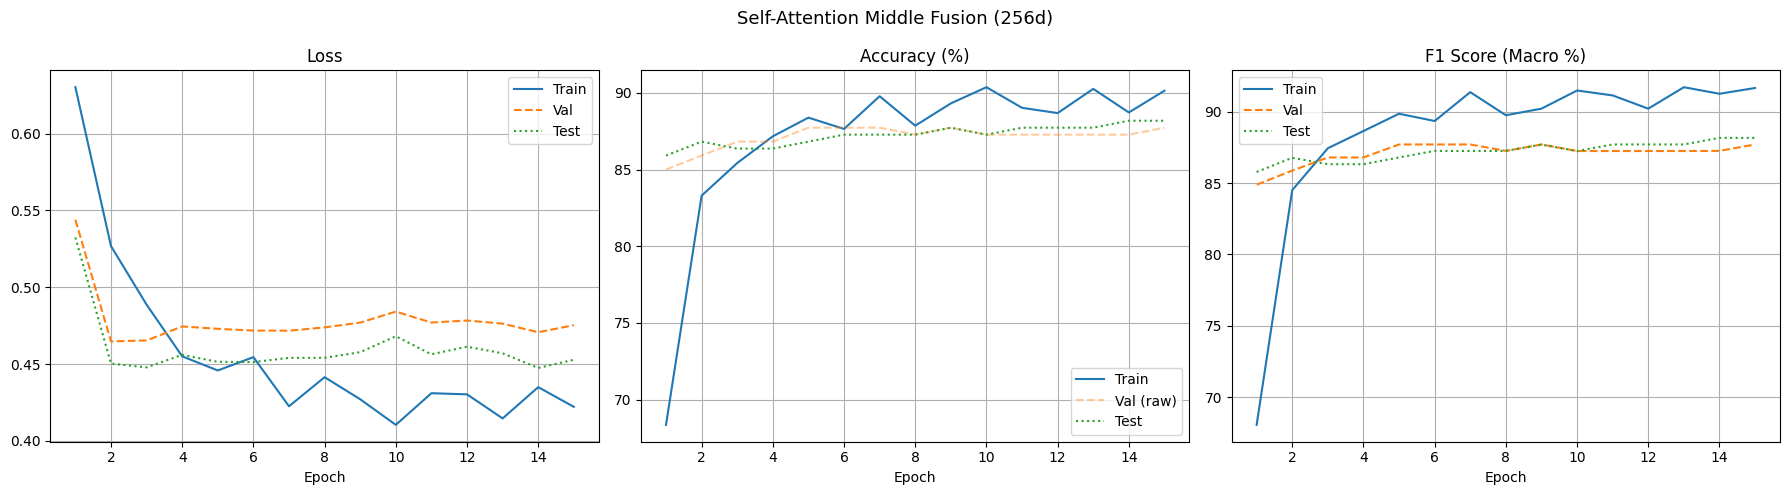


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       100         12
실제 Class 1 :       17          91
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 100개
• 0번인데 1번으로 오답 분류 (False Positive) : 12개
• 1번인데 0번으로 오답 분류 (False Negative) : 17개
• 정상 분류된 1번 감정 (True Positive)  : 91개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

     Class 0       0.85      0.89      0.87       112
     Class 1       0.88      0.84      0.86       108

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 13.72%
• Class 1번 감정 확률: 86.28%
------------------------------------------------------------


In [ ]:
model_256, hist_256 = run_experiment(
    in_dim     = 256,
    text_path  = "pkl/text_features_256(basic+earlystop).pkl",
    audio_path = "pkl/audio_feat_hubert_origin.pkl",
    video_path = "pkl/video_features_256.pkl",
    hyp        = hyp
)

# 기본+756


[실험 시작] 차원: 768d
데이터 로딩 중...
파라미터 수: 227,394
----------------------------------------------------------------------


Ep   1 Loss 0.644/0.524/0.524 | Acc 65.6/87.7/86.4% | F1 65.5/87.7/86.3% ✓
Ep   2 Loss 0.522/0.460/0.456 | Acc 83.7/87.7/87.3% | F1 85.0/87.7/87.3%
Ep   3 Loss 0.497/0.464/0.456 | Acc 82.9/87.3/88.6% | F1 84.5/87.3/88.6%
Ep   4 Loss 0.477/0.474/0.463 | Acc 85.2/86.8/87.7% | F1 86.8/86.8/87.7%
Ep   5 Loss 0.451/0.459/0.455 | Acc 87.6/86.8/89.1% | F1 89.4/86.8/89.1%
Ep   6 Loss 0.476/0.452/0.450 | Acc 84.9/87.3/88.6% | F1 87.0/87.3/88.6%
Ep   7 Loss 0.421/0.459/0.450 | Acc 90.6/87.7/89.5% | F1 92.0/87.7/89.5%
Ep   8 Loss 0.442/0.444/0.440 | Acc 88.1/86.8/89.5% | F1 89.9/86.8/89.5%
Ep   9 Loss 0.427/0.457/0.448 | Acc 87.9/87.7/89.5% | F1 88.8/87.7/89.5%
Ep  10 Loss 0.422/0.449/0.443 | Acc 89.2/87.7/89.1% | F1 90.4/87.7/89.1%
Ep  11 Loss 0.426/0.454/0.446 | Acc 89.7/87.3/89.1% | F1 91.7/87.3/89.1%
  → Early stop (epoch 11)

[768d] Best Val Acc  : 87.73%
[768d] 최종 Test Acc : 86.36%
[768d] 최종 Test F1  : 86.32%


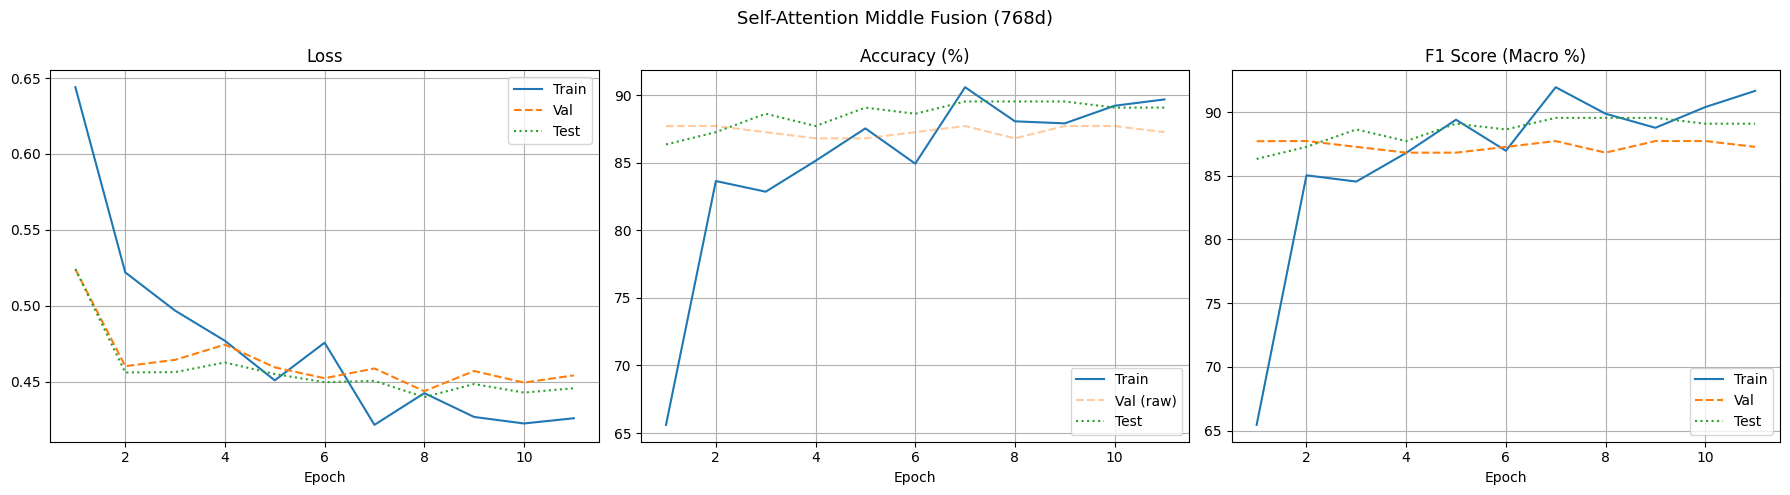


[1] 혼동 행렬 (Confusion Matrix) 분석
                예측 Class 0    예측 Class 1
실제 Class 0 :       101         11
실제 Class 1 :       19          89
------------------------------------------------------------
• 정상 분류된 0번 감정 (True Negative) : 101개
• 0번인데 1번으로 오답 분류 (False Positive) : 11개
• 1번인데 0번으로 오답 분류 (False Negative) : 19개
• 정상 분류된 1번 감정 (True Positive)  : 89개

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

     Class 0       0.84      0.90      0.87       112
     Class 1       0.89      0.82      0.86       108

    accuracy                           0.86       220
   macro avg       0.87      0.86      0.86       220
weighted avg       0.87      0.86      0.86       220


 [3] 개별 샘플 실시간 감정 추론 결과
------------------------------------------------------------
• Class 0번 감정 확률: 37.16%
• Class 1번 감정 확률: 62.84%
------------------------------------------------------------


In [ ]:
model_768, hist_768 = run_experiment(
    in_dim     = 768,
    text_path  = "pkl/text_features_768(basic+earlystop).pkl",
    audio_path = "pkl/audio_hubert_768.pkl",
    video_path = "pkl/video_features_768.pkl",
    hyp        = hyp
)